# Phase 4: Exploratory Data Analysis

## Objectives

In this final phase, you will:

1. Conduct comprehensive univariate analysis
2. Perform bivariate analysis to understand feature relationships
3. Analyze the target variable distribution
4. Identify key patterns and insights in the data
5. Validate assumptions and feature engineering decisions
6. Create visualizations that tell the story of house prices
7. Prepare final recommendations for modeling

## Instructions

EDA is both an art and a science. Look for patterns, anomalies, and insights that will guide modeling decisions.

---
## Task 1: Import Libraries and Load Data

In [1]:
# TODO: Import necessary libraries
# - pandas, numpy, matplotlib.pyplot, seaborn
# - from scipy import stats
# - import warnings

# TODO: Filter warnings (warnings.filterwarnings('ignore'))

# TODO: Set visualization style
# - sns.set_style('whitegrid')
# - plt.rcParams['figure.figsize'] = (12, 6)

# TODO: Set pandas display options
# - display.max_columns to None

# TODO: Print success message

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

pd.set_option('display.max_columns', None)

print("Success!")

Success!


In [2]:
# Load feature-engineered data

df = pd.read_csv('train_feature_engineered.csv')

# Load original cleaned data for categorical analysis

df_original = pd.read_csv('train_cleaned.csv')

# Extract target variable

y = df['SalePrice']

print(f"Feature-engineered dataset: {df.shape}")
print(f"Original dataset: {df_original.shape}")
print(f"Target variable: {y.shape}")

Feature-engineered dataset: (1460, 90)
Original dataset: (1460, 76)
Target variable: (1460,)


### Step 2.1: Statistical Summary of Target Variable

In [3]:
# TODO: Print comprehensive statistics for SalePrice
# Include: count, mean, median, std, min, max, range
# Include quartiles: Q1 (25%), Q2 (50%), Q3 (75%)
# Calculate skewness using stats.skew(y)
# Calculate kurtosis using stats.kurtosis(y)
# Format currency values with ${value:,.2f}

print("Count", len(y))
print(f"Mean: ${y.mean():,.2f}")
print(f"Median: ${y.median():,.2f}")
print(f"Std: ${y.std():,.2f}")
print(f"Min: ${y.min():,.2f}")
print(f"Max: ${y.max():,.2f}")
print(f"Range: ${y.max() - y.min():,.2f}")

print(f"Q1: ${y.quantile(0.25):,.2f}")
print(f"Q2: ${y.quantile(0.5):,.2f}")
print(f"Q3: ${y.quantile(0.75):,.2f}")

print(f"Skewness: {stats.skew(y):.2f}")
print(f"Kurtosis: {stats.kurtosis(y):.2f}")

Count 1460
Mean: $180,921.20
Median: $163,000.00
Std: $79,442.50
Min: $34,900.00
Max: $755,000.00
Range: $720,100.00
Q1: $129,975.00
Q2: $163,000.00
Q3: $214,000.00
Skewness: 1.88
Kurtosis: 6.51


### Step 2.2: Visualize Target Distribution

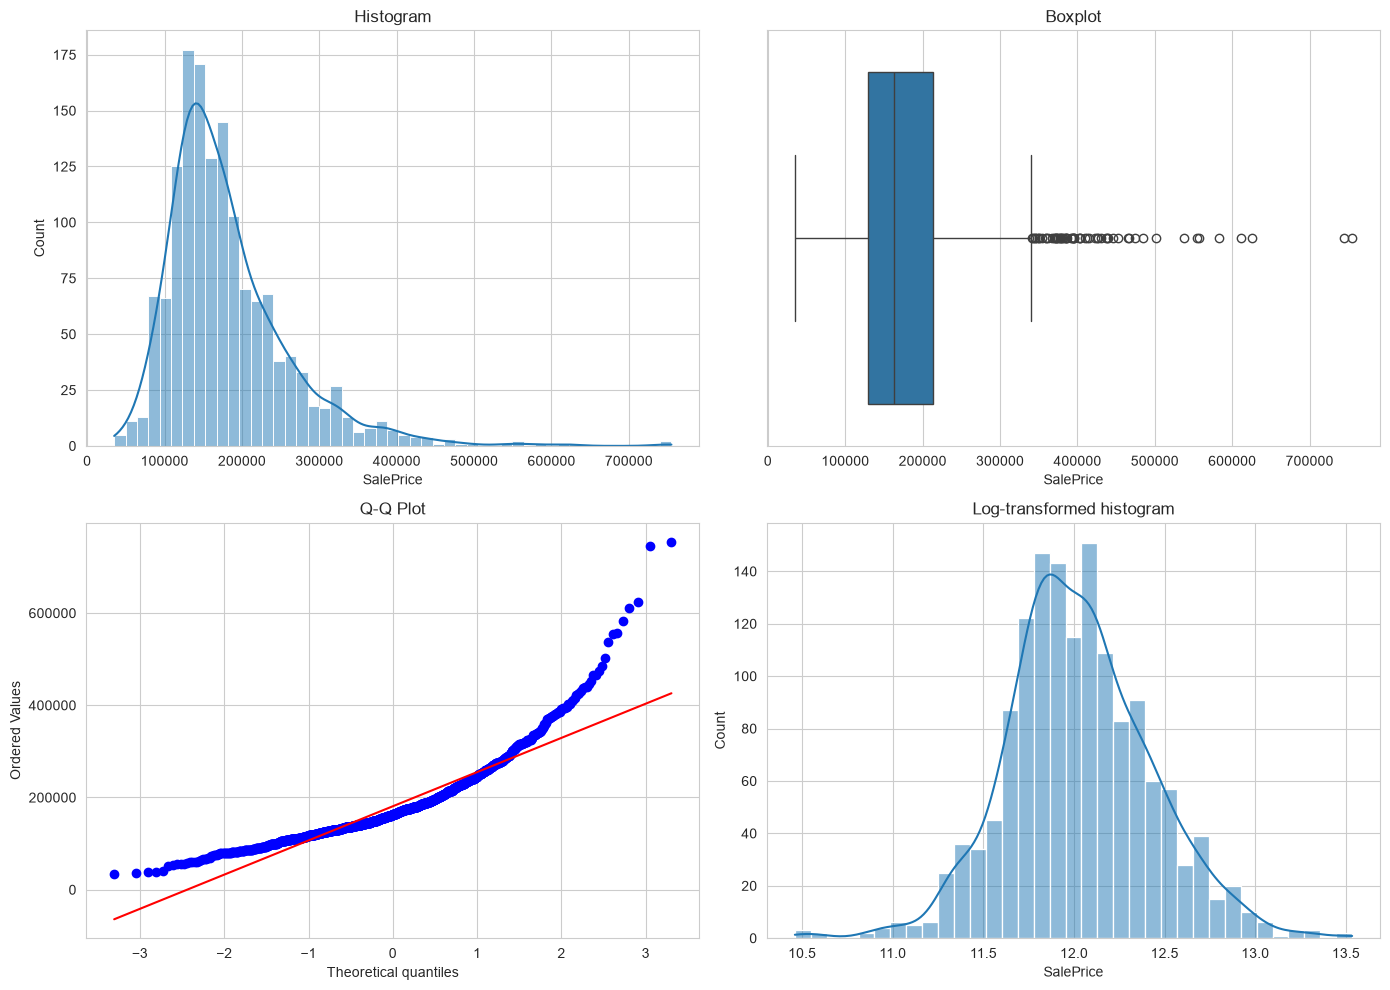

In [4]:
# TODO: Create 2x2 subplot for target variable visualization
# 1. Histogram with mean and median lines
# 2. Box plot
# 3. Q-Q plot (use stats.probplot())
# 4. Log-transformed histogram
# 
# Use fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Add titles, labels, and legends
# Use plt.tight_layout() and plt.show()


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(y, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Histogram')
axes[0, 0].set_xlabel('SalePrice')
axes[0, 0].set_ylabel('Count')

sns.boxplot(x = y, ax=axes[0, 1])
axes[0, 1].set_title('Boxplot')

stats.probplot(y, plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')


sns.histplot(np.log1p(y), kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Log-transformed histogram')
axes[1, 1].set_xlabel('SalePrice')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()


### Your Analysis:

Write your observations about the target variable:
- Is the distribution normal or skewed? yes. right-skewed
- Are there outliers? yes. we can see them clearly by looking boxplot
- What price range do most houses fall into? 100k-200k
- Does log transformation improve normality? yes.

---
## Task 3: Univariate Analysis - Numerical Features

Analyze individual numerical features.

In [5]:
# TODO: Get numerical features
# - Use select_dtypes to get columns with int64 and float64
# - Remove 'Id' column if present
# - Remove 'SalePrice' if present (we'll analyze it separately)
# - Store in numerical_features list

# TODO: Print count of numerical features being analyzed


numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if('Id' in numerical_features):
    numerical_features.remove('Id')

if ('SalePrice' in numerical_features):
    numerical_features.remove('SalePrice')

print("Count of numerical features:", len(numerical_features))

Count of numerical features: 50


### Step 3.1: Distribution Analysis of Key Numerical Features

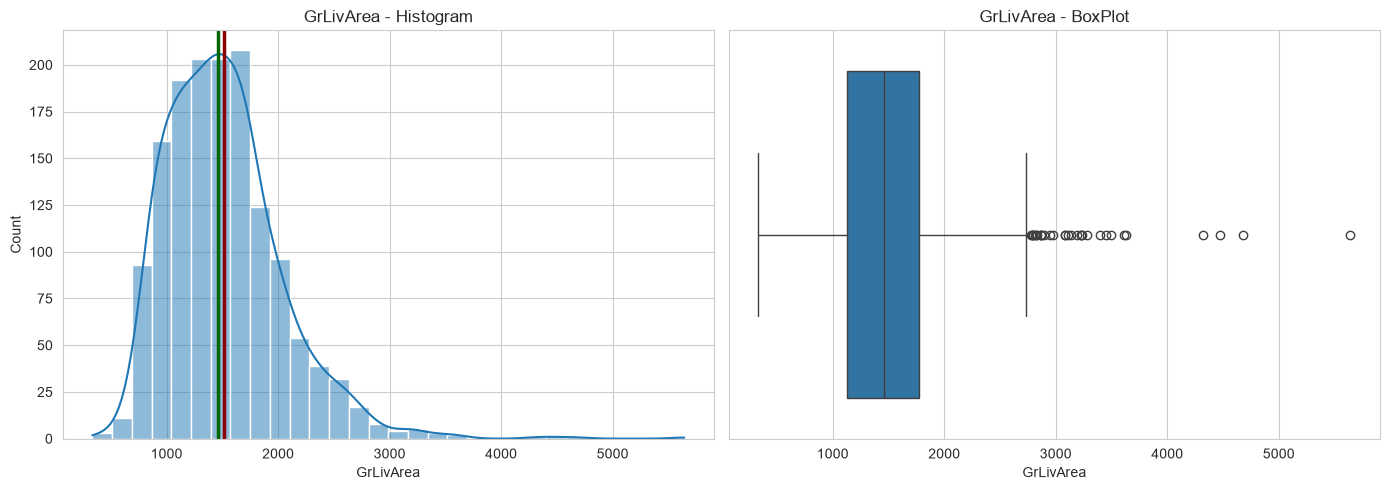

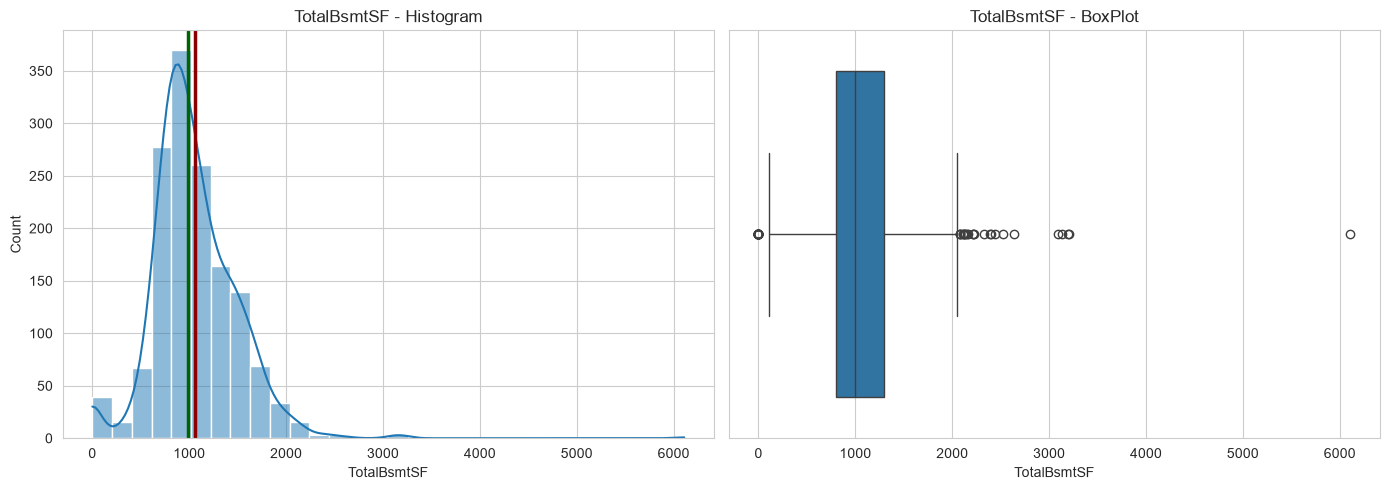

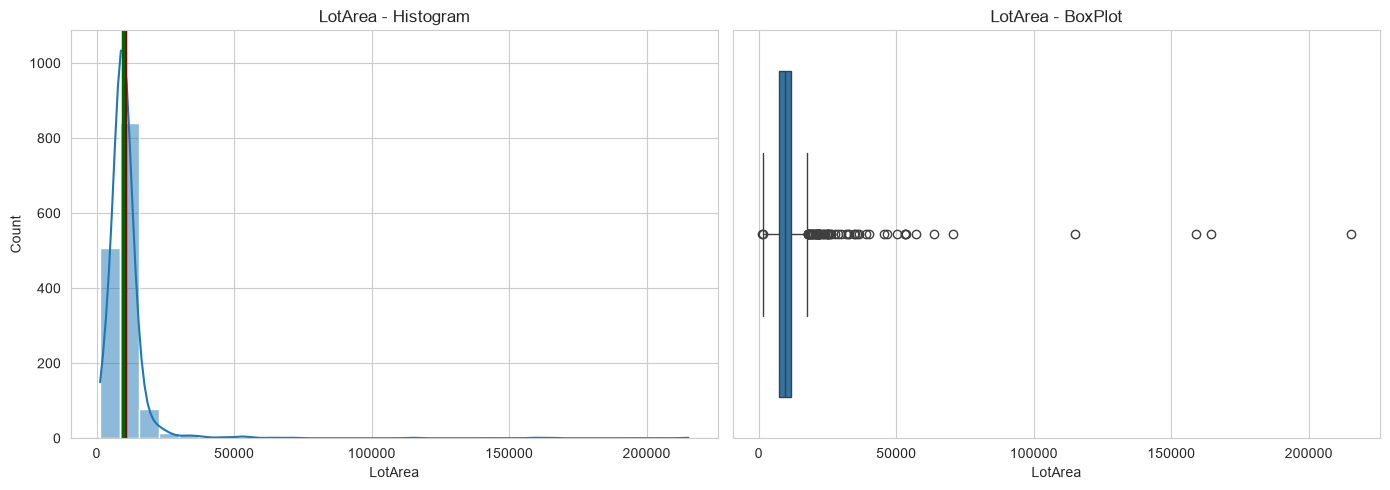

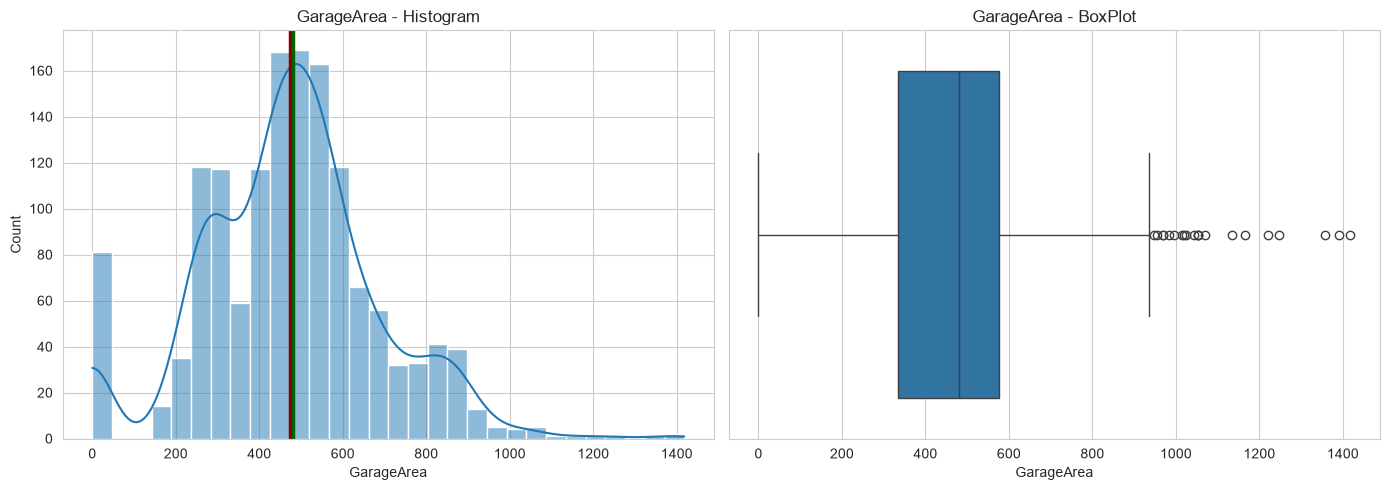

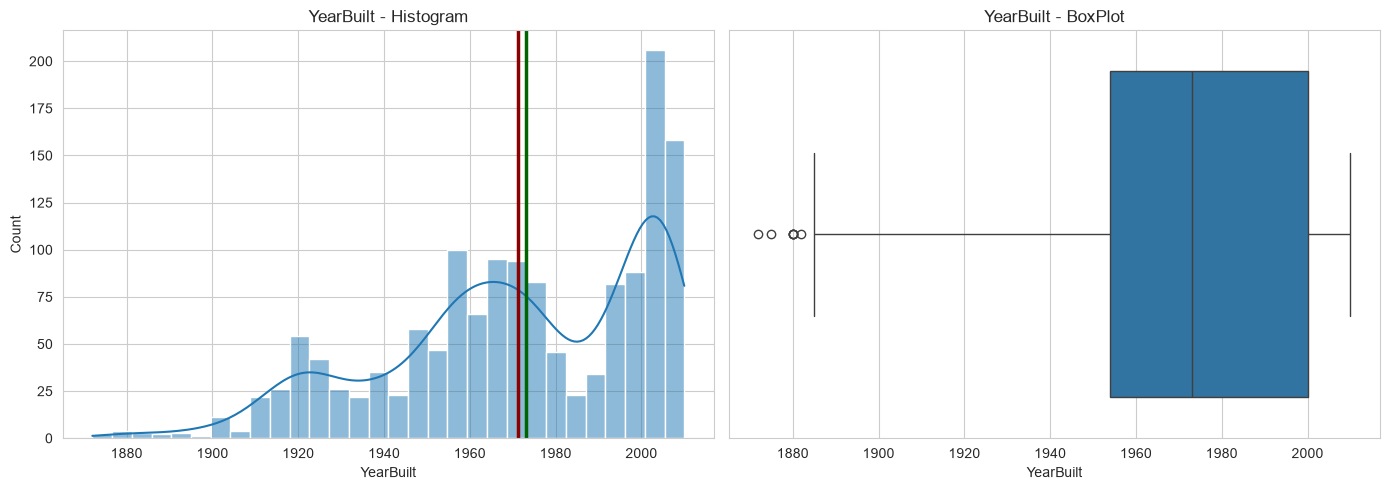

In [6]:
# TODO: Select key features to analyze
# Examples: GrLivArea, TotalBsmtSF, LotArea, GarageArea, YearBuilt
# - Filter features that exist in df_original
# - Store in key_features list

# TODO: Create distribution plots
# - Create subplots with 2 columns (histogram and boxplot)
# - For each feature:
#   * Left: Histogram with 30 bins
#   * Add mean and median lines
#   * Right: Boxplot
# - Use tight_layout and display


keys = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'GarageArea', 'YearBuilt']
key_features = [col for col in keys if col in df_original.columns]


for f in key_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df_original[f], bins = 30, kde=True, ax = axes[0])
    axes[0].axvline(df_original[f].mean(), color='darkred', linestyle='-', label=f'Mean: {df_original[f].mean():,.2f}', linewidth=2.5)
    axes[0].axvline(df_original[f].median(), color='darkgreen', linestyle='-', label=f'Median: {df_original[f].median():,.2f}', linewidth=2.5)
    axes[0].set_title(f'{f} - Histogram')
    axes[0].set_xlabel(f)
    axes[0].set_ylabel('Count')


    sns.boxplot( x = df_original[f], ax = axes[1])
    axes[1].set_title(f'{f} - BoxPlot')
    axes[1].set_xlabel(f)


    plt.tight_layout()
    plt.show()


---
## Task 4: Univariate Analysis - Categorical Features

Analyze distributions of categorical variables.

In [7]:
# TODO: Get categorical features
# - Use select_dtypes to get 'object' columns
# - Store in categorical_features list

# TODO: Print count of categorical features
# TODO: Print number of unique values for each categorical feature

categorical_features = df_original.select_dtypes(include=['object']).columns.tolist()

print("Count of categorical features:", len(categorical_features))
print("Number of unique values for each categorical feature:")
for f in categorical_features:
    print(f'{f}: {df_original[f].nunique()}')

Count of categorical features: 38
Number of unique values for each categorical feature:
MSZoning: 5
Street: 2
LotShape: 4
LandContour: 4
Utilities: 2
LotConfig: 5
LandSlope: 3
Neighborhood: 25
Condition1: 9
Condition2: 8
BldgType: 5
HouseStyle: 8
RoofStyle: 6
RoofMatl: 8
Exterior1st: 15
Exterior2nd: 16
ExterQual: 4
ExterCond: 5
Foundation: 6
BsmtQual: 4
BsmtCond: 4
BsmtExposure: 4
BsmtFinType1: 6
BsmtFinType2: 6
Heating: 6
HeatingQC: 5
CentralAir: 2
Electrical: 5
KitchenQual: 4
Functional: 7
FireplaceQu: 5
GarageType: 6
GarageFinish: 3
GarageQual: 5
GarageCond: 5
PavedDrive: 3
SaleType: 9
SaleCondition: 6


### Step 4.1: Visualize Key Categorical Features

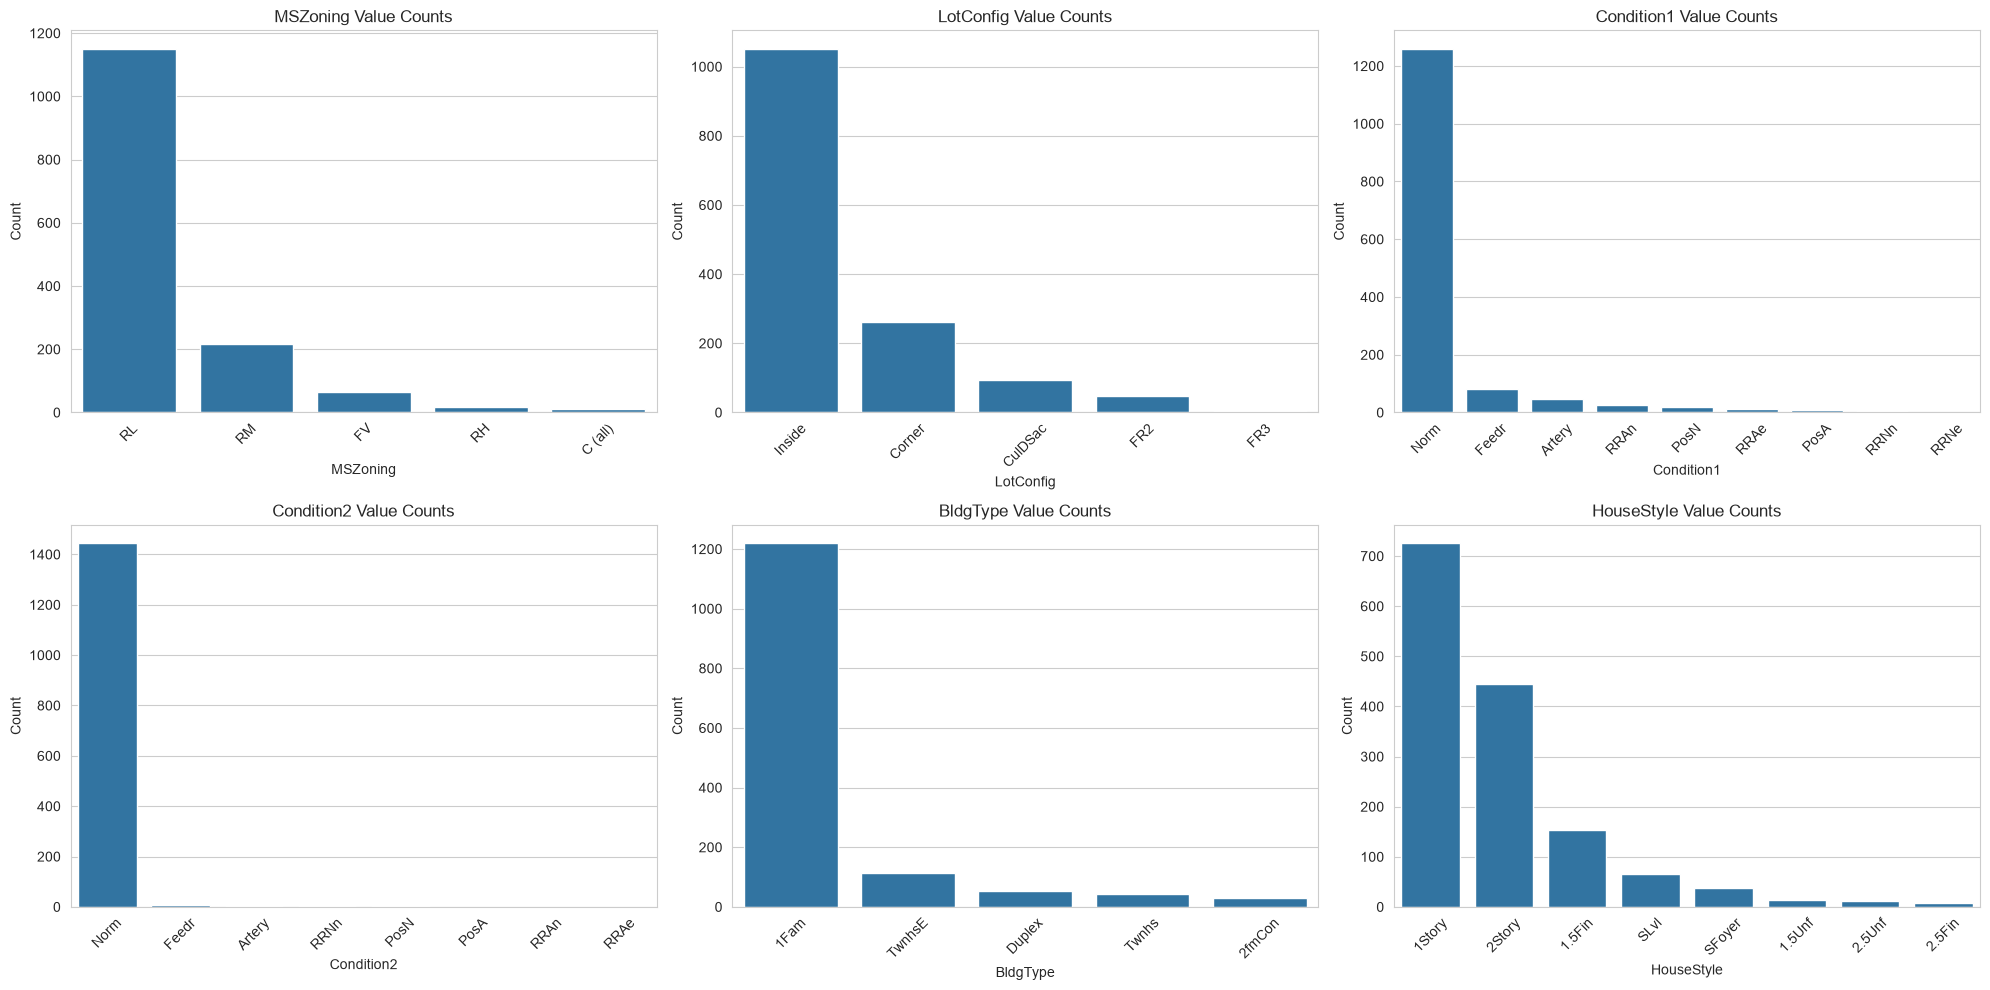

In [8]:
# TODO: Select key categorical features
# - Filter features with moderate cardinality (5-15 unique values)
# - Limit to 6 features for visualization

# TODO: Create bar plots
# - Create 2x3 subplot grid
# - For each feature:
#   * Get value counts
#   * Create bar plot
#   * Rotate x-labels for readability
# - Hide unused subplots
# - Display the figure


filter_cols = [col for col in df_original.select_dtypes(include=['object']).columns if 5 <= df_original[col].nunique() <= 15]

filter = filter_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, f in enumerate(filter):
    value_counts = df_original[f].value_counts()

    sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f'{f} Value Counts')
    axes[i].set_xlabel(f)
    axes[i].set_ylabel('Count')


for j in range(len(filter), len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()


---
## Task 5: Bivariate Analysis - Numerical vs Target

Analyze relationships between numerical features and SalePrice.

### Step 5.1: Correlation Analysis

In [9]:
# TODO: Calculate correlations
# - Select numerical columns
# - Calculate correlation matrix
# - Extract correlations with 'SalePrice'
# - Sort in descending order

# TODO: Print top 15 features most correlated with SalePrice



numerical_col = df_original.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_col.corr()
saleprice_corr = correlation_matrix['SalePrice'].sort_values(ascending=False)

print("Top 15 features most correlated with SalePrice:")
print(saleprice_corr.head(15))

Top 15 features most correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.334771
Name: SalePrice, dtype: float64


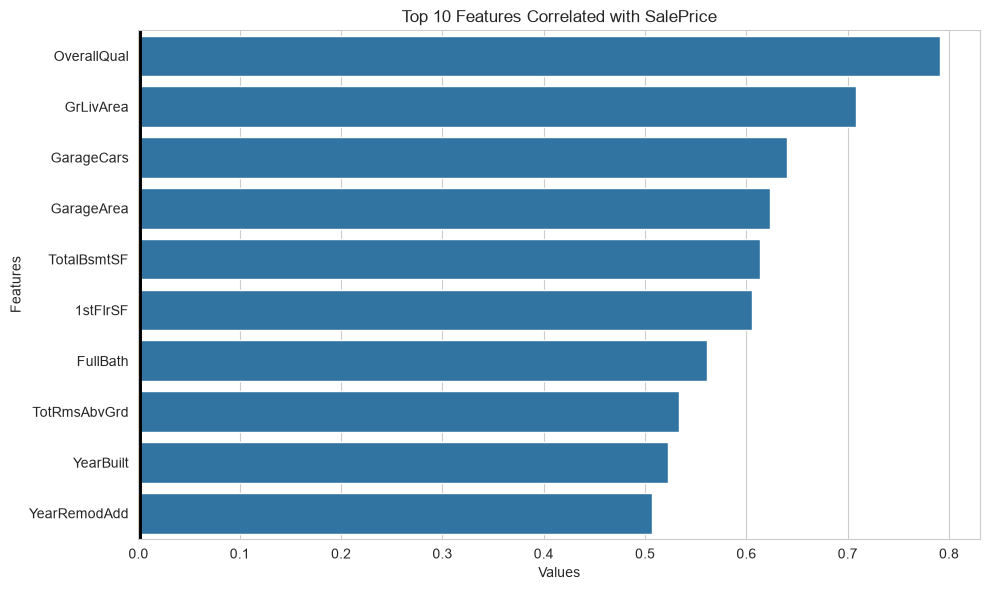

In [10]:
# TODO: Visualize top correlations
# - Get top 10 features (excluding SalePrice itself)
# - Create horizontal bar plot (figsize=(10, 6))
# - Add xlabel, title
# - Add vertical line at x=0
# - Display the plot

top_corr = saleprice_corr.drop('SalePrice').head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x = top_corr, y = top_corr.index)
plt.title('Top 10 Features Correlated with SalePrice')
plt.xlabel('Values')
plt.ylabel('Features')
plt.axvline(x = 0, color = 'black', linestyle = '-', linewidth = 5)

plt.tight_layout()
plt.show()

### Step 5.2: Scatter Plots of Top Features vs SalePrice

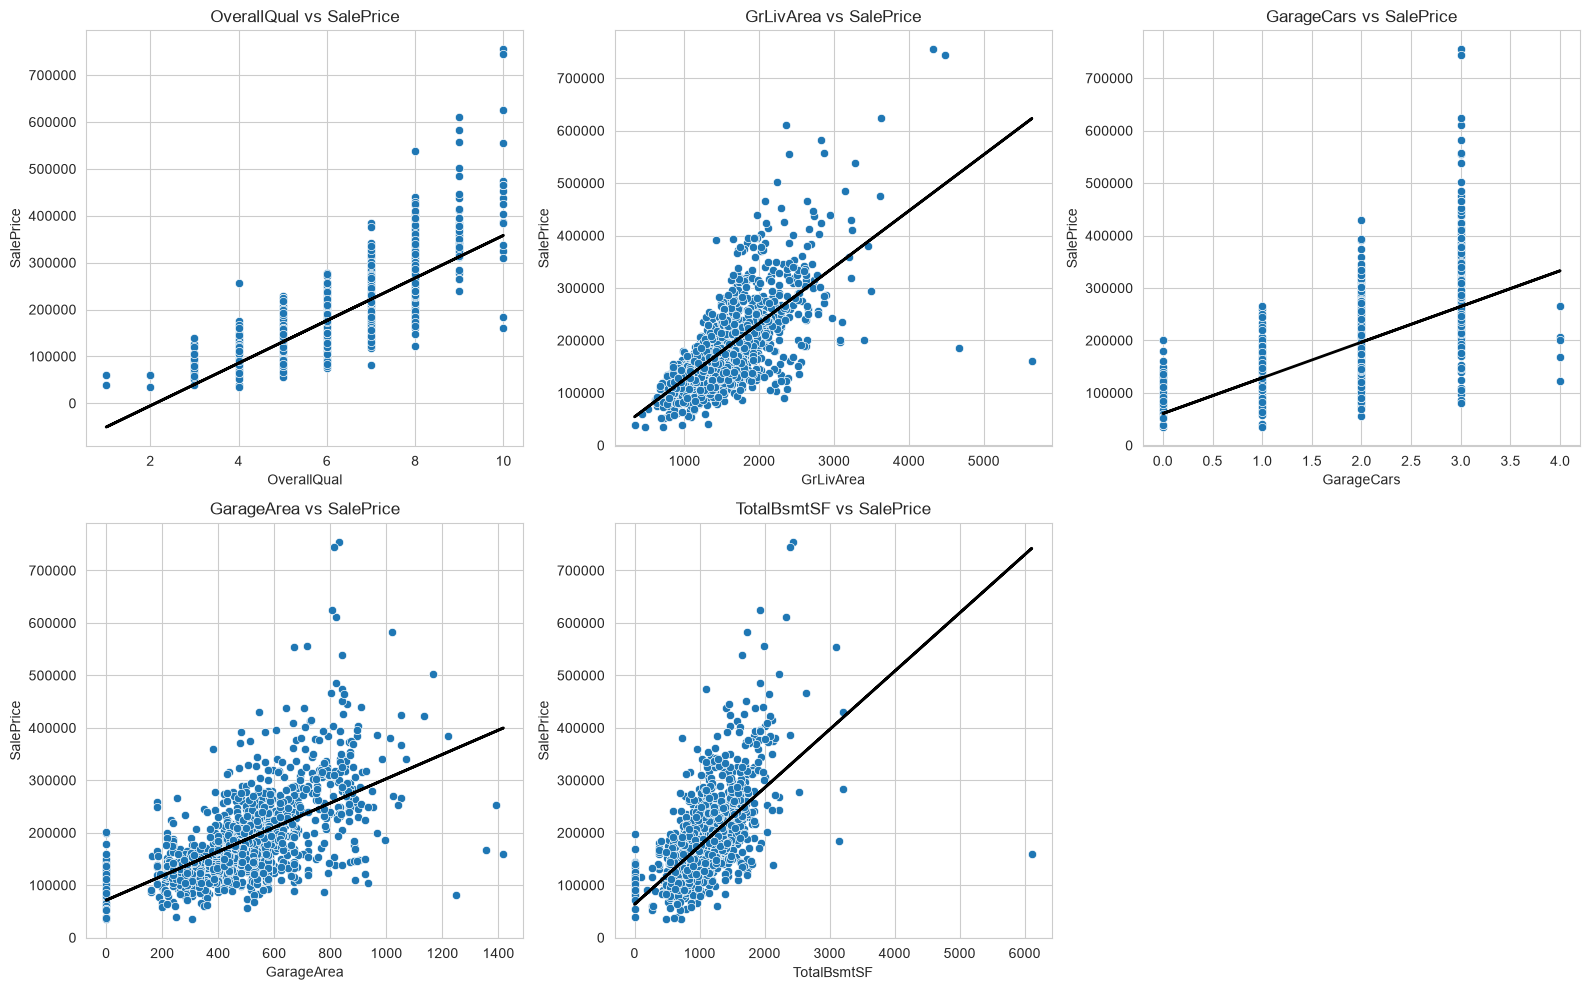

In [11]:
# TODO: Create scatter plots for top 5 correlated features
# - Create 2x3 subplot grid (figsize=(16, 10))
# - For each of top 5 features:
#   * Create scatter plot vs SalePrice
#   * Add trend line using np.polyfit
#   * Show correlation value in title
# - Hide unused subplot
# - Display the figure


top_5 = top_corr.head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, f in enumerate(top_5):
    sns.scatterplot(x = df_original[f], y=  df_original['SalePrice'], ax=axes[i])
    m, b = np.polyfit(df_original[f],df_original['SalePrice'] , 1)
    axes[i].plot(df_original[f], m * df_original[f] + b, color='black', linewidth=2)
    corr_val = top_corr[f]
    axes[i].set_title(f'{f} vs SalePrice')
    axes[i].set_xlabel(f)
    axes[i].set_ylabel('SalePrice')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

---
## Task 6: Bivariate Analysis - Categorical vs Target

Analyze how categorical features affect SalePrice.

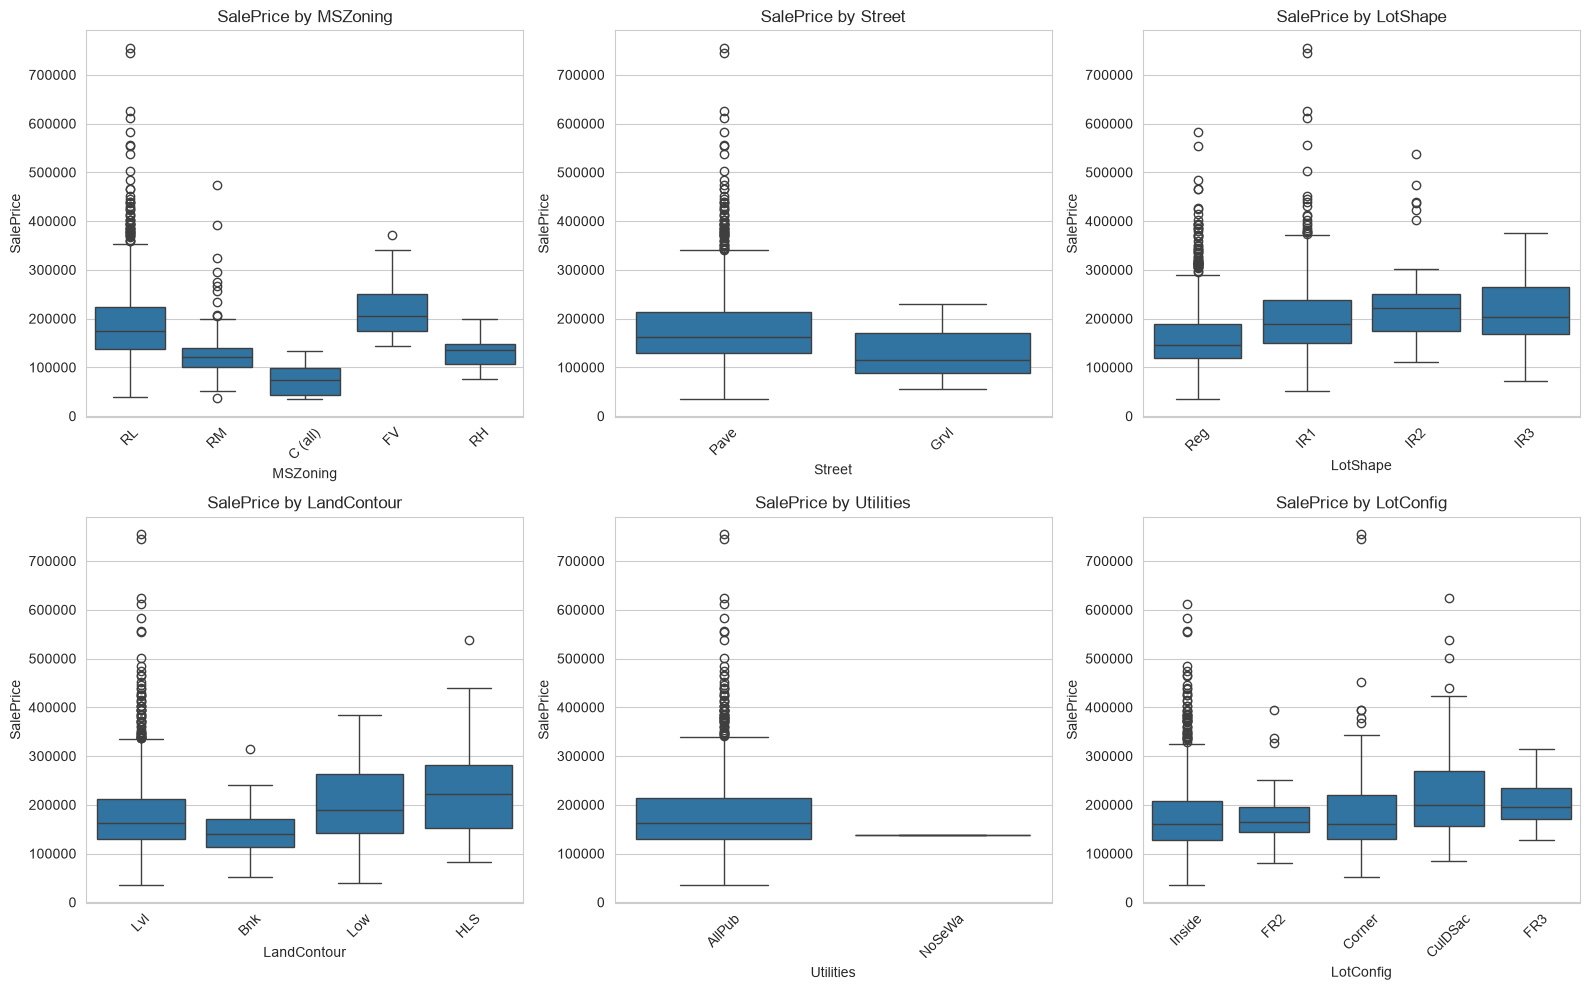

In [12]:
# TODO: Select categorical features with moderate cardinality
# - Filter features with 2-10 unique values
# - Limit to 6 features

# TODO: Create box plots
# - Create 2x3 subplot grid (figsize=(16, 10))
# - For each feature:
#   * Create boxplot of SalePrice by category
#   * Rotate x-labels for readability
# - Hide unused subplots
# - Display the figure


cat_features = [col for col in df_original.select_dtypes(include=['object', 'category']).columns if 2 <= df_original[col].nunique() <= 10][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, f in enumerate(cat_features):
    sns.boxplot(x=df_original[f], y=df_original['SalePrice'], ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f'SalePrice by {f}')
    axes[i].set_xlabel(f)
    axes[i].set_ylabel('SalePrice')

for j in range(len(cat_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Step 6.1: Statistical Analysis by Category

In [13]:
# TODO: Analyze mean price by categories
# - For top 3 categorical features:
#   * Group by feature
#   * Calculate count, mean, median, std of SalePrice
#   * Sort by mean in descending order
#   * Print the statistics table


top_3_cats = cat_features[:3]

for f in top_3_cats:
    stats = df_original.groupby(f)['SalePrice'].agg(['count', 'mean', 'median', 'std'])
    stats_sorted = stats.sort_values(by='mean', ascending=False)
    print("Statistics table by", f)
    print(stats_sorted)

Statistics table by MSZoning
          count           mean    median           std
MSZoning                                              
FV           65  214014.061538  205950.0  52369.662067
RL         1151  191004.994787  174000.0  80766.341319
RH           16  131558.375000  136500.0  35714.118435
RM          218  126316.830275  120500.0  48521.689833
C (all)      10   74528.000000   74700.0  33791.092031
Statistics table by Street
        count           mean    median           std
Street                                              
Pave     1454  181130.538514  163000.0  79446.597317
Grvl        6  130190.500000  114250.0  65446.253991
Statistics table by LotShape
          count           mean    median           std
LotShape                                              
IR2          41  239833.365854  221000.0  99669.427362
IR3          10  216036.500000  203570.0  82540.334855
IR1         484  206101.665289  189000.0  85858.489559
Reg         925  164754.818378  146000.0  6

---
## Task 7: Multivariate Analysis

Examine relationships between multiple features simultaneously.

### Step 7.1: Correlation Heatmap

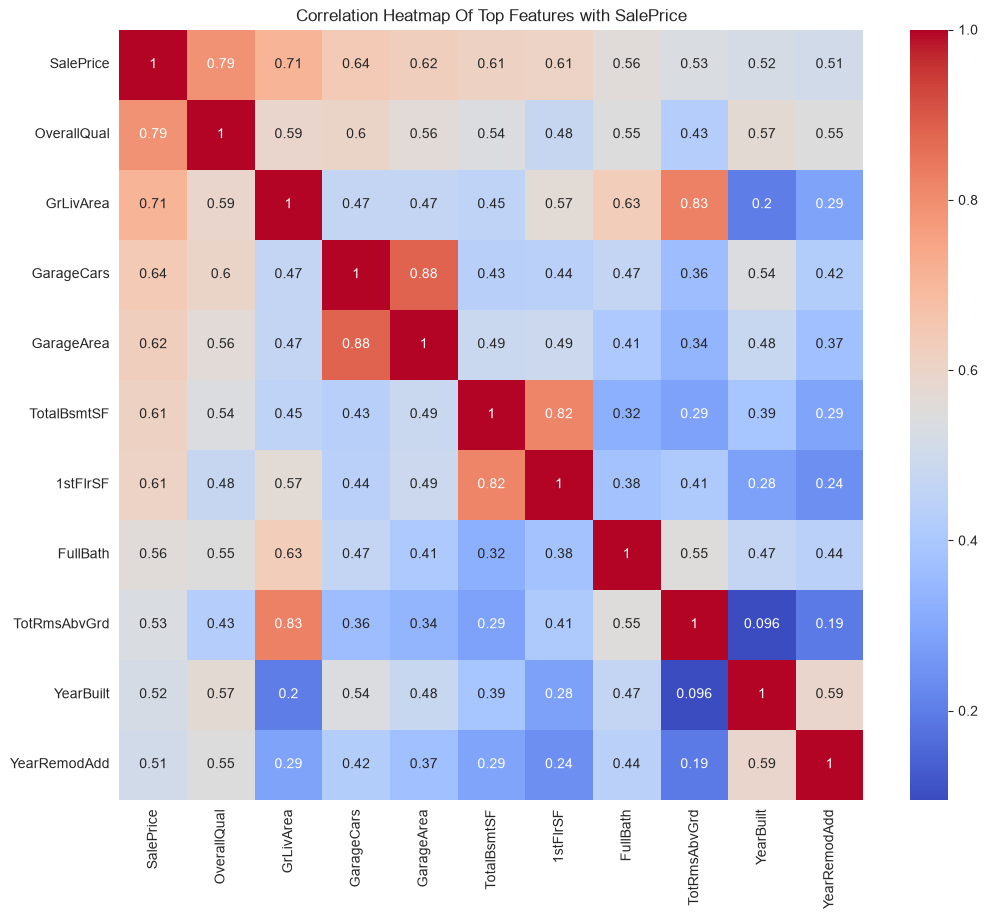

In [14]:
# TODO: Create correlation heatmap for top features
# - Get top 10-11 features plus SalePrice
# - Create correlation matrix
# - Create heatmap using seaborn (figsize=(12, 10))
# - Use coolwarm colormap with annotations
# - Add title and display

top_features = saleprice_corr.head(11).index.tolist()
corr_matrix_top = df_original[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_top, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap Of Top Features with SalePrice')

plt.show()

### Step 7.2: Pair Plot of Key Features

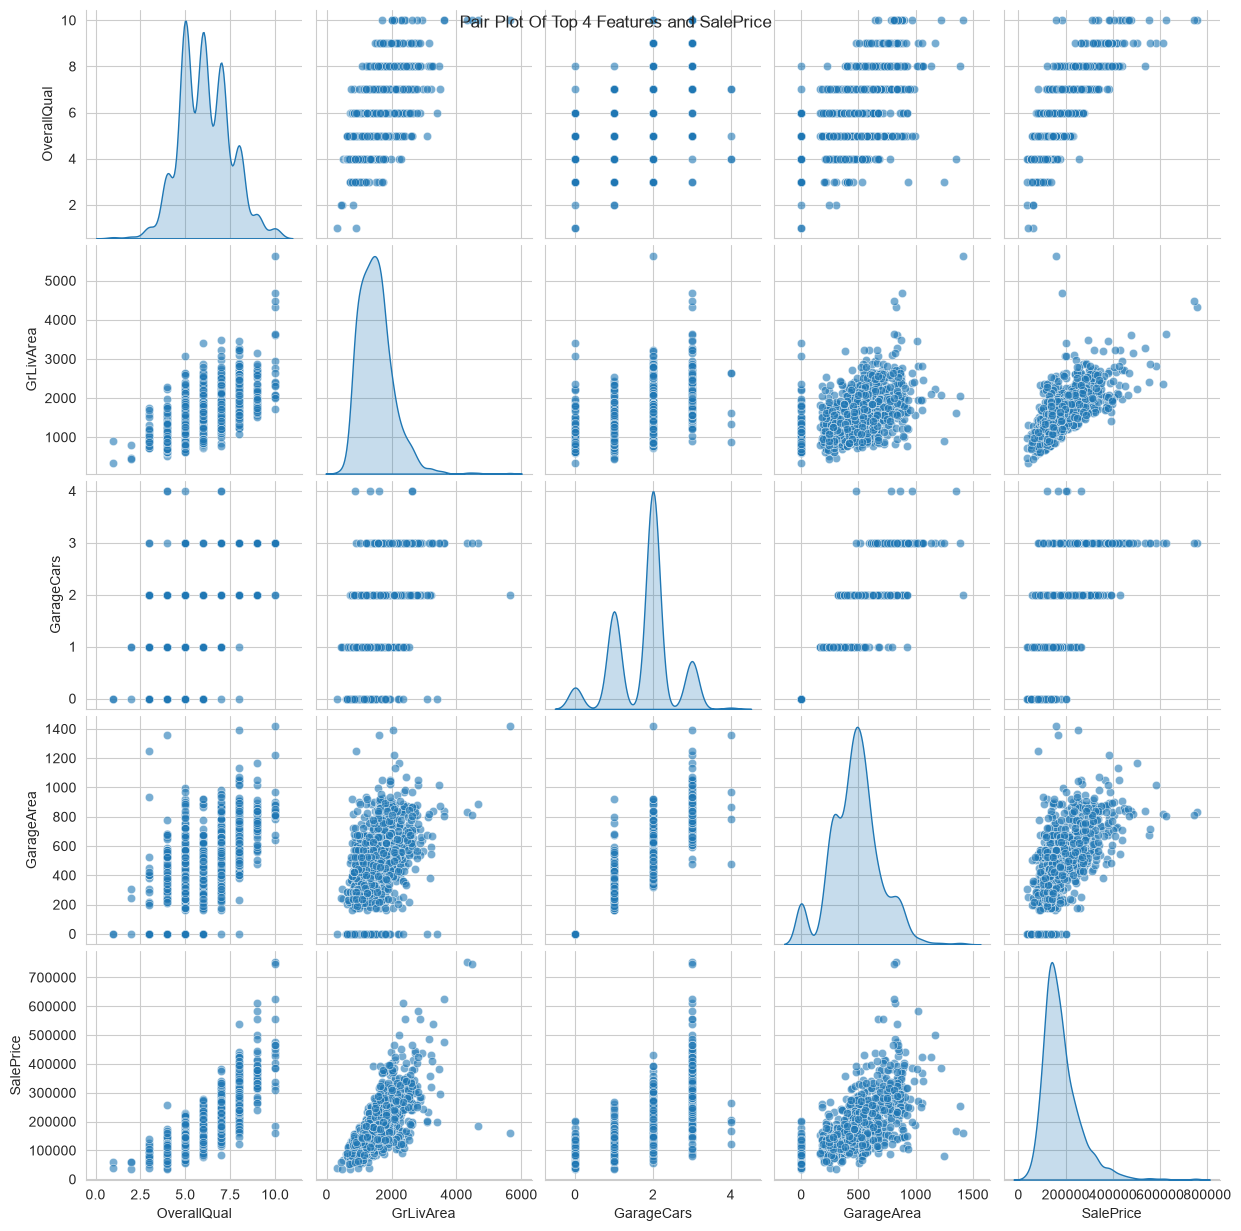

In [15]:
# TODO: Create pair plot for top features
# - Select top 4 features plus SalePrice
# - Create temporary dataframe with these features
# - Use sns.pairplot with diag_kind='kde'
# - Set plot transparency (alpha=0.6)
# - Add title and display
# Note: This may take a moment to generate

top_4_features = saleprice_corr.drop('SalePrice').head(4).index.tolist()
top_4_features = top_4_features + ['SalePrice']

temp_df = df_original[top_4_features]

mt = sns.pairplot(temp_df, diag_kind='kde', plot_kws={'alpha': 0.6})
mt.fig.suptitle('Pair Plot Of Top 4 Features and SalePrice')
plt.show()

---
## Task 8: Analyze Engineered Features

Evaluate the features you created in Phase 3.

In [16]:
# TODO: Load list of new features if available
# - Try to open 'new_features_list.txt'
# - Read and print the content
# - Handle FileNotFoundError if file doesn't exist
# Note: This file is created in Phase 3

try:
    print(open('new_features_list.txt').read())
except FileNotFoundError:
    print("There is no file")

New Features Created:--------------------------------------1. TotalSF
2. TotalBaths
3. TotalPorchSF
4. FinishedToUnfinishedRatio
5. LivingArea_to_LotArea
6. BasementRatio
7. HouseAge
8. IsNewHouse
9. HasSecondFloor
10. HasGarage
11. Quality_x_Area
12. Bath_x_Bed
13. OverallQual_Squared
14. GrLivArea_Squared



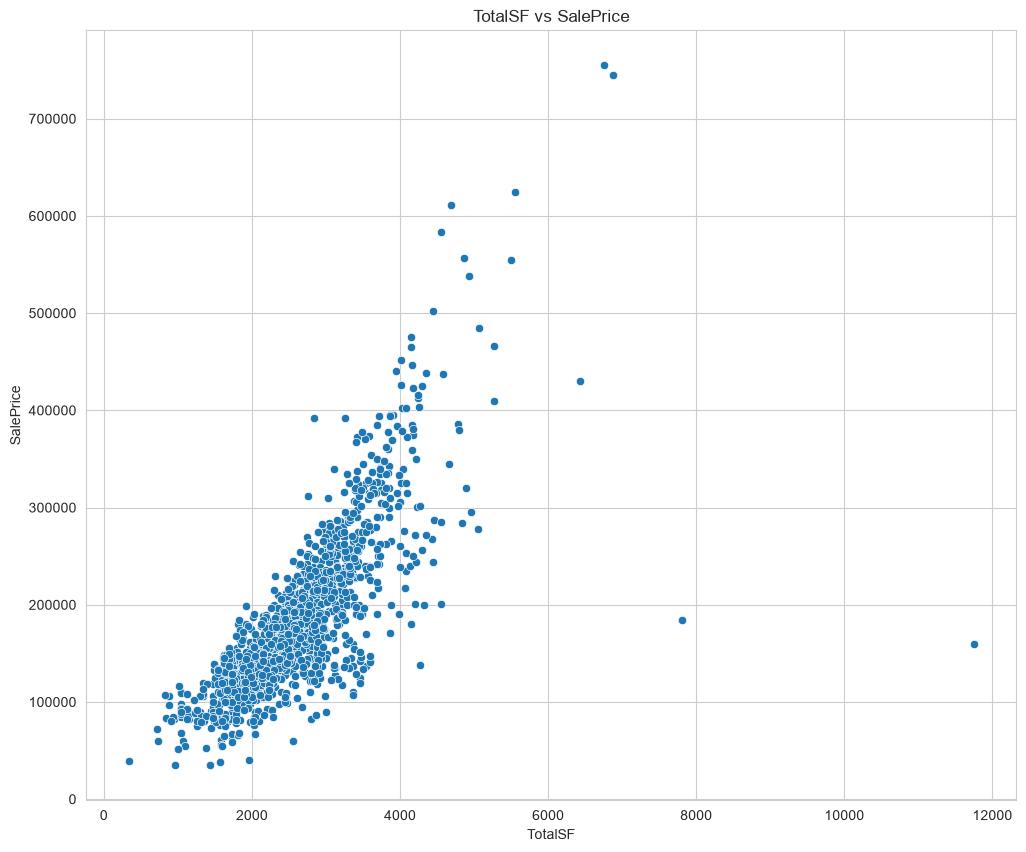

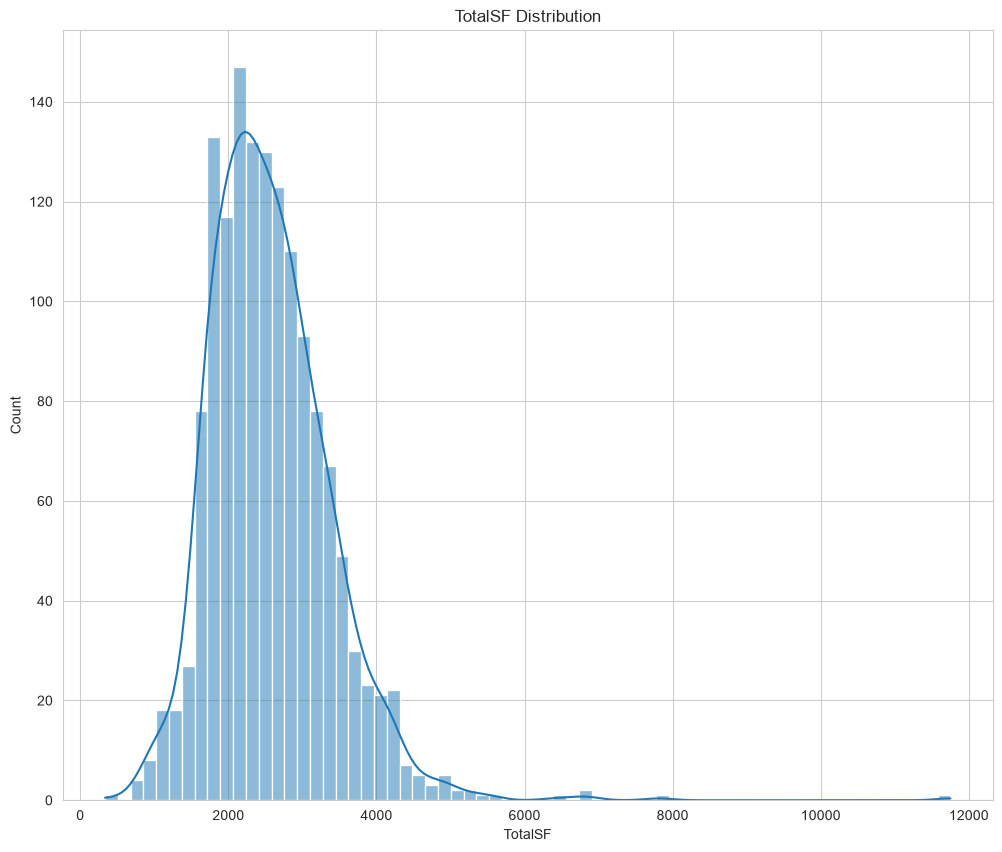

In [17]:
# TODO: Analyze engineered features
# If you created features like 'TotalSF' in Phase 3:
# - Create scatter plot of engineered feature vs SalePrice
# - Create histogram showing distribution of engineered feature
# - Compare correlation with target

# Your analysis of engineered features here
# Example structure provided in comments above

if 'TotalSF' in df.columns:
    plt.figure(figsize=(12, 10))
    sns.scatterplot(x=df['TotalSF'], y=df['SalePrice'])
    plt.title('TotalSF vs SalePrice')

    plt.figure(figsize=(12, 10))
    sns.histplot(df['TotalSF'], kde=True)
    plt.title('TotalSF Distribution')
    plt.show()

else:
    print("There is no file")

---
## Task 9: Key Insights and Patterns

Summarize the most important findings from your EDA.

### Step 9.1: Document Your Findings

Answer these questions based on your analysis:

#### 1. Target Variable (SalePrice)
- What is the typical price range? 100-300k
- Is the distribution normal or skewed? right-skewed
- Are there significant outliers? yes

#### 2. Most Important Features
- Which 5 features have the strongest correlation with SalePrice? OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF
- Are the relationships linear or non-linear? linear

#### 3. Categorical Insights
- Which categorical features show the biggest price differences? MSZoning, LotShape
- Are there any surprising patterns? I think no, generally data follows a linear pattern

#### 4. Feature Relationships
- Which features are highly correlated with each other? GarageCars and GarageArea, GrLivArea and TotRmsAbvGrd, TotalBsmtSF adn 1stFlrSF
- Does this suggest multicollinearity concerns? yes.

#### 5. Engineered Features
- Did your engineered features improve correlation with target? yes, TotalSF showed a stronger linear relationship and higher correlation with SalePrice
- Which engineered features are most promising? TotalSF

**Write your insights here:**

In [20]:
# TODO: Create a summary report
# Print the following sections:
# 1. DATASET OVERVIEW
#    - Total samples, features, numerical/categorical counts

print("=" * 60)
print("1. DATASET OVERVIEW")
print("=" * 60)
print(f"Total samples: {df_original.shape[0]}")
print(f"Total features: {df_original.shape[1]}")
print(f"Numerical features: {len(df_original.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Categorical features: {len(df_original.select_dtypes(include=['object', 'category']).columns)}")

# 2. TARGET VARIABLE (SalePrice)
#    - Mean, median, range, skewness

print("=" * 60)
print("2. TARGET VARIABLE (SalePrice)")
print("=" * 60)
print(f"Mean: {df_original['SalePrice'].mean()}")
print(f"Median: {df_original['SalePrice'].median()}")
print(f"Range: {df_original['SalePrice'].max() - df_original['SalePrice'].min()}")
print(f"Skewness: {df_original['SalePrice'].skew()}")
# 3. TOP 5 MOST CORRELATED FEATURES
#    - List features with correlation values

print("=" * 60)
print("3. TOP 5 MOST CORRELATED FEATURES")
print("=" * 60)
top_5 = saleprice_corr.drop('SalePrice').head(5)

for f, value in top_5.items():
    print(f"{f:} : {value}")

# 4. KEY OBSERVATIONS
#    - Add your observations based on the analysis
# 5. RECOMMENDATIONS FOR MODELING
#    - Add your recommendations

print("=" * 60)
print("4. KEY OBSERVATIONS")
print("=" * 60)
print("SalePrice is right-skewed because of high outliers")
print("OverallQual and GrLivArea have the strongest correlation with price")


print("=" * 60)
print("5. RECOMMENDATIONS FOR MODELING")
print("=" * 60)
print("We can delete multicollinearity")

# Use proper formatting with separators and alignment

1. DATASET OVERVIEW
Total samples: 1460
Total features: 76
Numerical features: 38
Categorical features: 38
2. TARGET VARIABLE (SalePrice)
Mean: 180921.19589041095
Median: 163000.0
Range: 720100
Skewness: 1.8828757597682129
3. TOP 5 MOST CORRELATED FEATURES
OverallQual : 0.7909816005838053
GrLivArea : 0.7086244776126515
GarageCars : 0.6404091972583519
GarageArea : 0.6234314389183622
TotalBsmtSF : 0.6135805515591943
4. KEY OBSERVATIONS
SalePrice is right-skewed because of high outliers
OverallQual and GrLivArea have the strongest correlation with price
5. RECOMMENDATIONS FOR MODELING
We can delete multicollinearity


---
## Task 10: Final Visualizations

Create compelling visualizations that tell the story of house prices.

Text(0.5, 1.0, 'Summary Text')

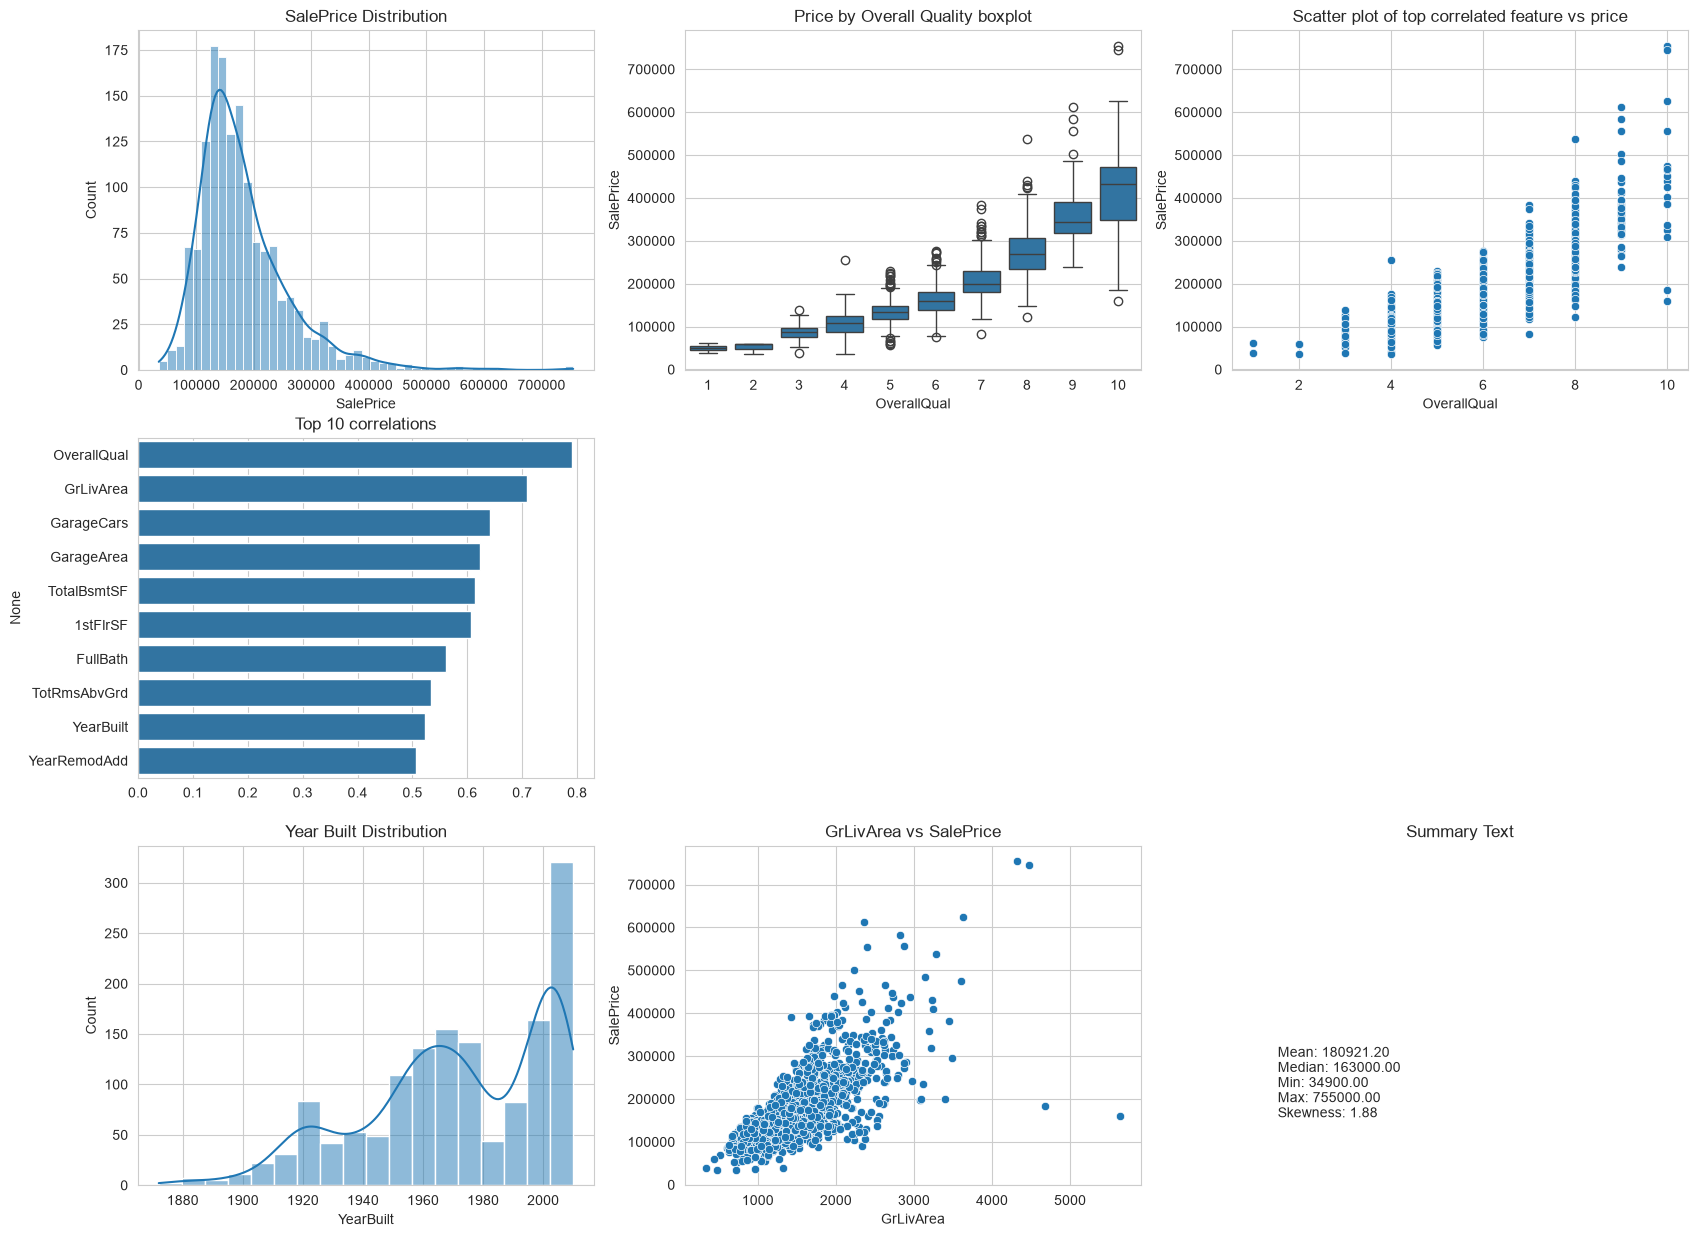

In [29]:
# TODO: Create a comprehensive dashboard-style visualization
# Create figure with 3x3 grid layout (figsize=(16, 12))

# Panel 1: Price distribution histogram
# Panel 2: Price by Overall Quality boxplot (if available)
# Panel 3: Scatter plot of top correlated feature vs price
# Panel 4: Horizontal bar chart of top 10 correlations (spans full row)
# Panel 5: Year Built distribution histogram
# Panel 6: Living Area vs Price scatter plot
# Panel 7: Summary statistics text box

# Add overall title for the dashboard
# Use proper spacing and formatting


fig, axes = plt.subplots(3, 3, figsize=(20, 15))

sns.histplot(df_original['SalePrice'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('SalePrice Distribution')

sns.boxplot(x='OverallQual', y='SalePrice', ax=axes[0, 1], data=df_original)
axes[0, 1].set_title('Price by Overall Quality boxplot')

top = saleprice_corr.drop('SalePrice').index[0]
sns.scatterplot(x=df_original[top], y='SalePrice', ax=axes[0, 2], data=df_original)
axes[0, 2].set_title('Scatter plot of top correlated feature vs price')

top_10 = saleprice_corr.drop('SalePrice').head(10)
sns.barplot(x=top_10.values, y=top_10.index, ax=axes[1, 0])
axes[1, 0].set_title('Top 10 correlations')

axes[1, 1].axis('off')
axes[1, 2].axis('off')

sns.histplot(df_original['YearBuilt'], kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Year Built Distribution')

sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_original, ax=axes[2, 1])
axes[2, 1].set_title('GrLivArea vs SalePrice')

axes[2, 2].axis('off')
summary_text = (
    f"Mean: {df_original['SalePrice'].mean():.2f}\n"
    f"Median: {df_original['SalePrice'].median():.2f}\n"
    f"Min: {df_original['SalePrice'].min():.2f}\n"
    f"Max: {df_original['SalePrice'].max():.2f}\n"
    f"Skewness: {df_original['SalePrice'].skew():.2f}")
axes[2, 2].text(0.1, 0.2,summary_text)
axes[2, 2].set_title("Summary Text")



---
## Summary and Final Reflection

### What You Accomplished:

1. Conducted comprehensive analysis of the target variable
2. Performed univariate analysis on numerical and categorical features
3. Executed bivariate analysis to understand feature-target relationships
4. Conducted multivariate analysis using correlation matrices and pair plots
5. Evaluated engineered features from Phase 3
6. Identified key patterns and insights in the data
7. Created professional visualizations
8. Documented findings and recommendations

### Key Takeaways:

EDA is an iterative process that helps you:
- Understand your data deeply
- Identify potential issues before modeling
- Generate hypotheses about relationships
- Make informed decisions about feature selection and engineering
- Communicate insights to stakeholders

### Critical Questions for Final Reflection:

1. What are the 3 most important factors affecting house prices in this dataset? OverallQual, GrLivArea, GarageArea
2. Did your EDA reveal any unexpected patterns or relationships? no I did not see.
3. Are there any features that should be excluded from modeling? Why? Id - because it has zero predictive power. multicollinear metrics
4. What transformations will be most important for modeling success? log transformation maybe. because data is right skewed.
5. Based on your EDA, what modeling approaches seem most appropriate? lineear regression because I can see linear connection between features and target variablee.
6. What additional features might improve predictions? TotalSF, HouseAge, RemodAge, TotalBaths.

### Next Steps (After Linear Regression Lessons):

Once you learn Linear Regression, you will:
1. Build baseline models using the cleaned and preprocessed data
2. Train regression models to predict house prices
3. Evaluate model performance using appropriate metrics
4. Iterate on feature engineering based on model results
5. Create predictions for the test dataset
6. Submit your predictions to Kaggle

### Congratulations!

You have completed a comprehensive data preparation workflow covering:
- Data Cleaning
- Data Preprocessing  
- Feature Engineering
- Exploratory Data Analysis

Your data is now ready for machine learning modeling. Excellent work!